# Laboratori 9 · Ushtrime Shtesë — Rrjedha Max / Prerja Min: nga Përkufizimi te Ford-Fulkerson

> **Lidhja me leksionin:** *Leksionet 5–6 — Rrjedha Max / Prerja Min* (slides 2–79).
>
> Laboratorët 8–9 e treguan algoritmin me animacione. Këtu e **ndërtoni vetë**, pjesë pas pjese,
> ashtu siç e ndërton leksioni: rrjedha e lejueshme → prerja → pse dështon algoritmi greedy →
> rrjeta mbetëse → `rritRrjedhë` → Ford-Fulkerson → Edmonds-Karp → teorema rrjedhë-max = prerje-min.
> Nuk kërkon Pygame.

| # | Ushtrimi | Slides |
|:-:|---|:-:|
| 1 | A është rrjedhë e lejueshme? Vlera e rrjedhës | 11–17 |
| 2 | Kapaciteti i një $s$-$t$ prerjeje · dualiteti i dobët | 7–10, 20–23 |
| 3 | Pse dështon algoritmi greedy | 26–36 |
| 4 | Rrjeta mbetëse $G_f$ | 37–39 |
| 5 | `rritRrjedhë` — rritja përgjatë një rruge rritëse | 40–46 |
| 6 | Ford-Fulkerson (DFS) dhe Edmonds-Karp (BFS) | 47–58, 74 |
| 7 | Shembulli me $C$: pse ka rëndësi zgjedhja e rrugës | 66–74 |
| 8 | Prerja min nga rrjeta mbetëse — teorema | 59–64, 76 |

## Kujtues teorik — Përkufizimet e leksionit

**Rrjeta rrjedhë** (slide 5): digraf $G = (V, E)$ me një **burim** $s$ dhe një **derdhje** $t$; çdo brinjë
$(u, v)$ ka **kapacitet** $c(u, v) \ge 0$.

**$s$-$t$ prerje** (slide 7): copëtim $(S, T)$ i $V$ me $s \in S$, $t \in T$. **Kapaciteti** i saj:
$$c(S, T) = \sum_{e \text{ dalëse nga } S} c(e)$$
— vetëm brinjët **nga $S$ te $T$**. Brinjët nga $T$ te $S$ **nuk** numërohen.

**Rrjedha** (slide 15): funksion $f : E \to \mathbb{R}_{\ge 0}$ i tillë që
- **kufizimi i kapacitetit:** $0 \le f(e) \le c(e)$ për çdo $e \in E$;
- **ruajtja e rrjedhës:** për çdo $v \in V \setminus \{s, t\}$: $\sum_{e \text{ hyrëse në } v} f(e) = \sum_{e \text{ dalëse nga } v} f(e)$.

**Vlera:** $v(f) = \sum_{e \text{ dalëse nga } s} f(e) - \sum_{e \text{ hyrëse në } s} f(e)$.

**Lema 1 — dualiteti i dobët** (slide 21): për **çdo** rrjedhë $f$ dhe **çdo** prerje $(S,T)$: $v(f) \le c(S,T)$.

**Rrjeta mbetëse** $G_f$ (slide 37): për çdo $(u,v) \in E$ ka brinjë të drejtë me kapacitet mbetës
$c(u,v) - f(u,v)$ dhe brinjë kthyese $(v, u)$ me kapacitet mbetës $f(u,v)$. $E_f$ = brinjët me kapacitet mbetës
**rigorozisht pozitiv**. Një rrugë $s \to t$ në $G_f$ quhet **rrugë rritëse**.

```
rritRrjedhë(rrugë P në G_f, rrjedhë f):          Ford-Fulkerson(G):
    x = min i peshave të brinjëve në P               f ← të gjitha brinjët me zero rrjedhë
    for (u, v) në P:                                  G_f ← G
        if (u, v) në E:  f'(u, v) ← f(u, v) + x       while t është e arritshme nga s në G_f:
        if (v, u) në E:  f'(v, u) ← f(v, u) − x           gjej një rrugë P nga s në t në G_f   // DFS ose BFS
    return f'                                             f ← rritRrjedhë(P, f)
                                                          rinovo G_f
                                                      return f
```

> **Shënim për laboratorët 8–9.** Aty kushtet e rrjedhës shkruhen me **antisimetri** $f(u,v) = -f(v,u)$ —
> konventa e disa teksteve (p.sh. CLRS botimi i 2-të) që e bën kodin më të shkurtër. Leksioni përdor
> $f \ge 0$ vetëm mbi brinjët e $E$, plus brinjë **kthyese** në $G_f$. Të dyja japin të njëjtin algoritëm dhe
> të njëjtën vlerë rrjedhe; në këtë fletore ndjekim konventën e **leksionit**.

In [1]:
# ── Mjeti i kontrollit ──────────────────────────────────────────────
# Ekzekutojeni këtë qelizë një herë, në fillim. Pas çdo ushtrimi, qeliza
# "kontrollo(...)" teston funksionin tuaj dhe ju tregon nëse është gati.

def kontrollo(titulli, testet):
    try:
        testet()
    except NotImplementedError:
        print(f"⏳ {titulli}: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.")
    except AssertionError as e:
        print(f"✗ {titulli}: {e}")
    except Exception as e:
        print(f"✗ {titulli}: kodi u ndal me gabim  {type(e).__name__}: {e}")
    else:
        print(f"✓ {titulli}: të gjitha testet kaluan!")


# ── Paraqitja ───────────────────────────────────────────────────────
#   c = {("s", "a"): 10, ...}    kapacitetet e brinjëve të E
#   f = {("s", "a"): 4, ...}     rrjedha mbi të njëjtat brinjë
# Supozojmë (si leksioni) që nuk ka njëkohësisht (u, v) dhe (v, u) në E.

def kulmet(c):
    return {u for u, _ in c} | {v for _, v in c}


def pasi_plotesohet(fn):
    # Ekzekuton një demonstrim që varet nga funksionet tuaja.
    try:
        fn()
    except NotImplementedError:
        print("⏳ Ky rezultat shfaqet pasi të plotësoni ushtrimin e mësipërm.")

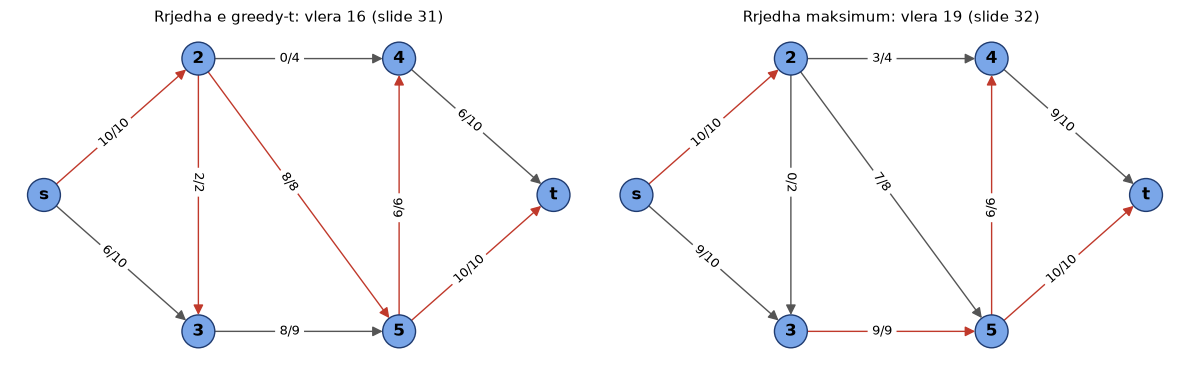

Brinjët e kuqe janë të ngopura: f(e) = c(e).


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Rrjeta e leksionit (slides 26–32)
G1 = {("s", "2"): 10, ("s", "3"): 10, ("2", "3"): 2, ("2", "4"): 4, ("2", "5"): 8,
      ("3", "5"): 9, ("5", "4"): 6, ("4", "t"): 10, ("5", "t"): 10}
POS1 = {"s": (0, 0), "2": (1, 1), "3": (1, -1), "4": (2.3, 1), "5": (2.3, -1), "t": (3.3, 0)}

# Rrjedha që gjen algoritmi greedy (slide 31) dhe rrjedha maksimum (slide 32)
F_GREEDY = {("s", "2"): 10, ("s", "3"): 6, ("2", "3"): 2, ("2", "4"): 0, ("2", "5"): 8,
            ("3", "5"): 8, ("5", "4"): 6, ("4", "t"): 6, ("5", "t"): 10}
F_MAX = {("s", "2"): 10, ("s", "3"): 9, ("2", "3"): 0, ("2", "4"): 3, ("2", "5"): 7,
         ("3", "5"): 9, ("5", "4"): 6, ("4", "t"): 9, ("5", "t"): 10}


def vizato_rrjeten(c, f=None, titulli="", pos=None, S=None, ax=None, mbetese=False):
    # Vizaton rrjetën me etiketa "f/c" (ose kapacitetet mbetëse nëse mbetese=True).
    G = nx.DiGraph(); G.add_edges_from(c)
    pos = pos or nx.spring_layout(G, seed=1)
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 3.6))
    ngjyra = ["#f2a65a" if S and v in S else "#7aa6e8" for v in G.nodes]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=ngjyra, node_size=560, edgecolors="#1f3b70")
    nx.draw_networkx_labels(G, pos, ax=ax, font_weight="bold")
    for (u, v) in G.edges:
        kthyese = (v, u) in c
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax, arrows=True, arrowsize=15, node_size=560,
                               connectionstyle=f"arc3,rad={0.18 if kthyese else 0}",
                               edge_color="#c0392b" if (f and f.get((u, v), 0) == c[(u, v)] and not mbetese) else "#555")
    if mbetese:
        etiketa = {e: str(c[e]) for e in c}
    else:
        etiketa = {e: (f"{f.get(e, 0)}/{c[e]}" if f is not None else str(c[e])) for e in c}
    te_perkulura = {e: l for e, l in etiketa.items() if (e[1], e[0]) in c}
    te_drejta = {e: l for e, l in etiketa.items() if e not in te_perkulura}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=te_drejta, ax=ax, font_size=9, label_pos=0.45)
    if te_perkulura:
        try:
            nx.draw_networkx_edge_labels(G, pos, edge_labels=te_perkulura, ax=ax, font_size=9,
                                         label_pos=0.45, connectionstyle="arc3,rad=0.18")
        except TypeError:                 # versione të vjetra të NetworkX
            nx.draw_networkx_edge_labels(G, pos, edge_labels=te_perkulura, ax=ax, font_size=9, label_pos=0.3)
    ax.set_title(titulli, fontsize=11); ax.axis("off")
    return ax


fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
vizato_rrjeten(G1, F_GREEDY, "Rrjedha e greedy-t: vlera 16 (slide 31)", POS1, ax=axs[0])
vizato_rrjeten(G1, F_MAX, "Rrjedha maksimum: vlera 19 (slide 32)", POS1, ax=axs[1])
plt.tight_layout(); plt.show()
print("Brinjët e kuqe janë të ngopura: f(e) = c(e).")

## Ushtrimi 1 — A është rrjedhë e lejueshme?

**Detyra:**
1. `vlera(f, s)` — $v(f)$: rrjedha që del nga $s$ minus rrjedha që hyn në $s$.
2. `eshte_rrjedhe(c, f, s, t)` — `True` nëse $f$ plotëson **kufizimin e kapacitetit** për çdo brinjë dhe
   **ruajtjen e rrjedhës** në çdo kulm të ndryshëm nga $s$ dhe $t$. Brinjët që mungojnë në `f` kanë rrjedhë 0.

In [3]:
def vlera(f, s):
    # PLOTESO
    raise NotImplementedError


def eshte_rrjedhe(c, f, s, t):
    # PLOTESO: kontrolloni 0 ≤ f(e) ≤ c(e), pastaj hyrjen = daljen për çdo v ≠ s, t
    raise NotImplementedError

In [4]:
def _testet():
    assert vlera(F_GREEDY, "s") == 16 and vlera(F_MAX, "s") == 19, "vlerat duhet të jenë 16 dhe 19"
    assert vlera({("a", "s"): 2, ("s", "a"): 5}, "s") == 3, "rrjedha që HYN në s zbritet"
    assert eshte_rrjedhe(G1, F_GREEDY, "s", "t") and eshte_rrjedhe(G1, F_MAX, "s", "t")
    assert eshte_rrjedhe(G1, {}, "s", "t"), "rrjedha zero është gjithmonë e lejueshme"
    tej = dict(F_MAX); tej[("2", "3")] = 3
    assert not eshte_rrjedhe(G1, tej, "s", "t"), "f(2,3) = 3 > c(2,3) = 2 — shkel kapacitetin"
    pa_ruajtje = dict(F_MAX); pa_ruajtje[("4", "t")] = 8
    assert not eshte_rrjedhe(G1, pa_ruajtje, "s", "t"), "kulmi 4: hyjnë 9, dalin 8 — shkel ruajtjen"
    negative = dict(F_MAX); negative[("2", "3")] = -1; negative[("2", "4")] = 4
    assert not eshte_rrjedhe(G1, negative, "s", "t"), "rrjedha negative nuk lejohet"

kontrollo("Ushtrimi 1 — Rrjedha e lejueshme", _testet)

⏳ Ushtrimi 1 — Rrjedha e lejueshme: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


## Ushtrimi 2 — Kapaciteti i një prerjeje (slides 7–10)

Kuizi i slide 10 ka katër përgjigje — dhe vetëm njëra numëron **vetëm** brinjët që dalin nga $S$.

**Detyra:** `kapaciteti_i_prerjes(c, S)` — shuma e kapaciteteve të brinjëve $(u, v)$ me $u \in S$ dhe $v \notin S$.

Kur testet kalojnë, qeliza provon **të gjitha** $2^4 = 16$ prerjet e rrjetës `G1` dhe verifikon dy fakte të leksionit:
- rrjedha **neto** nëpër çdo prerje është e njëjtë: $v(f)$ (*"e gjithë rrjedha duhet të kalojë nëpërmjet prerjes"*);
- **dualiteti i dobët:** $v(f) \le c(S, T)$ për çdo prerje.

In [5]:
def kapaciteti_i_prerjes(c, S):
    # PLOTESO
    raise NotImplementedError

In [6]:
from itertools import combinations

def te_gjitha_prerjet(c, s, t):
    mes = sorted(kulmet(c) - {s, t})
    for k in range(len(mes) + 1):
        for nen in combinations(mes, k):
            yield {s, *nen}


def _testet():
    assert kapaciteti_i_prerjes(G1, {"s"}) == 20
    assert kapaciteti_i_prerjes(G1, {"s", "2"}) == 2 + 4 + 8 + 10, "S={s,2}: s→3, 2→3, 2→4, 2→5"
    assert kapaciteti_i_prerjes(G1, {"s", "3"}) == 10 + 9, \
        "S={s,3}: vetëm s→2 dhe 3→5 dalin nga S. Brinja 2→3 HYN në S — nuk numërohet!"
    assert kapaciteti_i_prerjes(G1, {"s", "2", "3", "4", "5"}) == 20

    print(f"   {'S':<26} | c(S,T) | rrjedha neto e F_MAX nëpër prerje")
    min_c, min_S = float("inf"), None
    for S in te_gjitha_prerjet(G1, "s", "t"):
        cap = kapaciteti_i_prerjes(G1, S)
        neto = sum(F_MAX[e] for e in G1 if e[0] in S and e[1] not in S) - \
               sum(F_MAX[e] for e in G1 if e[1] in S and e[0] not in S)
        assert neto == vlera(F_MAX, "s"), "rrjedha neto nëpër prerje duhet të jetë v(f)"
        assert vlera(F_MAX, "s") <= cap, "dualiteti i dobët u shkel?!"
        if cap < min_c:
            min_c, min_S = cap, S
        print(f"   {str(sorted(S)):<26} | {cap:>6} | {neto}")
    print(f"\n   Prerja minimum: S = {sorted(min_S)}, kapaciteti {min_c} = v(F_MAX) = {vlera(F_MAX, 's')}")

kontrollo("Ushtrimi 2 — Kapaciteti i prerjes", _testet)

⏳ Ushtrimi 2 — Kapaciteti i prerjes: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


> **Pyetje:** cila nga 16 prerjet ka kapacitetin më të vogël? Pse fakti që $v(F\_MAX)$ është **i barabartë**
> me këtë kapacitet **vërteton** që `F_MAX` është rrjedhë maksimum — pa provuar asnjë rrjedhë tjetër?

## Ushtrimi 3 — Pse dështon algoritmi greedy (slides 26–36)

> *Nis me $f = 0$. Gjej një $s$-$t$ rrugë ku çdo brinjë ka $f(e) < c(e)$. Shto rrjedhë përgjatë saj. Përsërit.*

Algoritmi më poshtë e zbaton këtë ide fjalë për fjalë. Ndiqni rrugët që zgjedh dhe krahasojini me slides 28–31.

In [7]:
def greedy(c, s, t, rendi):
    # `rendi[u]` = rendi në të cilin eksplorohen fqinjët e u (për të riprodhuar slides).
    f = {e: 0 for e in c}
    while True:
        rruga, vizituar = None, set()
        def dfs(u, shteg):
            nonlocal rruga
            if u == t:
                rruga = shteg; return True
            vizituar.add(u)
            for v in rendi.get(u, []):
                if v not in vizituar and f[(u, v)] < c[(u, v)] and dfs(v, shteg + [v]):
                    return True
            return False
        if not dfs(s, [s]):
            return f
        x = min(c[(u, v)] - f[(u, v)] for u, v in zip(rruga, rruga[1:]))
        for u, v in zip(rruga, rruga[1:]):
            f[(u, v)] += x
        print(f"rruga {' → '.join(rruga):<20} shton {x}   vlera = {sum(f[e] for e in c if e[0] == s)}")


RENDI_G1 = {"s": ["2", "3"], "2": ["5", "3", "4"], "3": ["5"], "5": ["t", "4"], "4": ["t"]}
f_g = greedy(G1, "s", "t", RENDI_G1)
print("Greedy ndalon me vlerë", sum(f_g[e] for e in G1 if e[0] == "s"), "— por maksimumi është 19.\n")

# Slide 33: rrjeta e vogël ku e vetmja rrjedhë max ka f(u, v) = 0
G_ROMB = {("s", "u"): 2, ("s", "v"): 2, ("u", "v"): 1, ("u", "t"): 2, ("v", "t"): 2}
f_r = greedy(G_ROMB, "s", "t", {"s": ["u", "v"], "u": ["v", "t"], "v": ["t"]})
print("Greedy ndalon me vlerë", sum(f_r[e] for e in G_ROMB if e[0] == "s"), "— por maksimumi është 4.")

rruga s → 2 → 5 → t        shton 8   vlera = 8
rruga s → 2 → 3 → 5 → t    shton 2   vlera = 10
rruga s → 3 → 5 → 4 → t    shton 6   vlera = 16
Greedy ndalon me vlerë 16 — por maksimumi është 19.

rruga s → u → v → t        shton 1   vlera = 1
rruga s → u → t            shton 1   vlera = 2
rruga s → v → t            shton 1   vlera = 3
Greedy ndalon me vlerë 3 — por maksimumi është 4.


> **Përgjigjja e leksionit (slide 33):** *nëse algoritmi greedy shton rrjedhë në një brinjë, nuk e zvogëlon
> asnjëherë.* Na duhet një mekanizëm që të **"zhbëjë"** një vendim të keq → **brinjët kthyese** të rrjetës mbetëse.

## Ushtrimi 4 — Rrjeta mbetëse Gf (slides 37–39)

$$
c_f(x, y) = \begin{cases} c(x, y) - f(x, y) & \text{nëse } (x, y) \in E \quad \text{(brinjë e drejtë: sa mbetet)} \\
f(y, x) & \text{nëse } (y, x) \in E \quad \text{(brinjë kthyese: sa mund të zhbëjmë)} \end{cases}
$$

**Detyra:** `rrjeta_mbetese(c, f)` — kthen fjalorin `{(x, y): c_f(x, y)}` me **vetëm** brinjët që kanë
$c_f > 0$ (slide 37: *"$E_f$ — të gjitha brinjët që kanë kapacitet rigorozisht pozitiv"*).

In [8]:
def rrjeta_mbetese(c, f):
    # PLOTESO: për çdo (u, v) në c: brinja e drejtë (u, v) dhe brinja kthyese (v, u)
    raise NotImplementedError

In [9]:
def _testet():
    assert rrjeta_mbetese({("u", "v"): 17}, {("u", "v"): 6}) == {("u", "v"): 11, ("v", "u"): 6}, \
        "slide 37: c=17, f=6 → c_f(u,v)=11, c_f(v,u)=6"
    assert rrjeta_mbetese({("u", "v"): 5}, {("u", "v"): 5}) == {("v", "u"): 5}, \
        "brinja e ngopur zhduket nga G_f (kapacitet mbetës 0)"
    assert rrjeta_mbetese(G1, {}) == G1, "me rrjedhë zero, G_f = G"
    Gf = rrjeta_mbetese(G1, F_GREEDY)
    assert ("s", "2") not in Gf and Gf[("2", "s")] == 10, "s→2 është e ngopur"
    assert Gf[("3", "2")] == 2, "brinja kthyese 3→2 lejon të zhbëjmë 2 njësitë mbi 2→3"
    assert len(Gf) == 12, f"G_f e rrjedhës greedy ka 12 brinjë (4 të drejta + 8 kthyese), ju keni {len(Gf)}"

kontrollo("Ushtrimi 4 — Rrjeta mbetëse", _testet)

⏳ Ushtrimi 4 — Rrjeta mbetëse: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


In [10]:
def _demo():
    Gf = rrjeta_mbetese(G1, F_GREEDY)
    vizato_rrjeten(Gf, None, "G_f për rrjedhën greedy (vlera 16)", POS1, mbetese=True)
    plt.gcf().set_size_inches(7, 4); plt.show()
    print("A ka rrugë s → t në G_f? Ndiqni: s → 3 → 2 → 4 → t   (kalon brinjën kthyese 3 → 2)")

pasi_plotesohet(_demo)

⏳ Ky rezultat shfaqet pasi të plotësoni ushtrimin e mësipërm.


## Ushtrimi 5 — `rritRrjedhë` (slide 46)

**Detyra:** `rrit_rrjedhe(c, f, P)` — `P` është lista e kulmeve të një rruge rritëse në $G_f$. Ktheni një
**fjalor të ri** $f'$ (mos e ndryshoni `f`):
1. $x$ = kapaciteti mbetës minimal përgjatë $P$ (ngushtica);
2. për çdo hap $(u, v)$ të $P$: nëse $(u,v) \in E$ shtoni $x$ te $f(u,v)$; nëse $(v,u) \in E$ zbritni $x$ nga $f(v,u)$.

In [11]:
def rrit_rrjedhe(c, f, P):
    # PLOTESO
    raise NotImplementedError

In [12]:
def _testet():
    kopje = dict(F_GREEDY)
    f2 = rrit_rrjedhe(G1, F_GREEDY, ["s", "3", "2", "4", "t"])
    assert F_GREEDY == kopje, "rrit_rrjedhe nuk duhet ta ndryshojë f-në hyrëse"
    assert f2[("2", "3")] == 0 and f2[("s", "3")] == 8 and f2[("2", "4")] == 2, \
        "x = 2: f(s,3) 6→8, f(2,3) 2→0 (brinjë kthyese!), f(2,4) 0→2, f(4,t) 6→8"
    assert eshte_rrjedhe(G1, f2, "s", "t") and vlera(f2, "s") == 18, "rrjedha e re duhet të jetë e lejueshme me vlerë 18"
    f3 = rrit_rrjedhe(G1, f2, ["s", "3", "5", "2", "4", "t"])
    assert eshte_rrjedhe(G1, f3, "s", "t") and vlera(f3, "s") == 19, "pas rrugës së dytë rritëse vlera bëhet 19"
    f_romb = {("s", "u"): 2, ("u", "v"): 1, ("u", "t"): 1, ("s", "v"): 1, ("v", "t"): 2}   # slide 35, vlera 3
    r = rrit_rrjedhe(G_ROMB, f_romb, ["s", "v", "u", "t"])
    assert r[("u", "v")] == 0 and vlera(r, "s") == 4, "slide 36: brinja kthyese v→u zhbën rrjedhën mbi u→v"

kontrollo("Ushtrimi 5 — rritRrjedhë", _testet)

⏳ Ushtrimi 5 — rritRrjedhë: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


## Ushtrimi 6 — Ford-Fulkerson dhe Edmonds-Karp (slides 47, 74)

Leksioni thotë: *gjej një rrugë $P$ nga $s$ në $t$ në $G_f$ — p.sh. përdor DFS ose BFS.*
Dy funksionet e kërkimit janë dhënë. **Detyra:** plotësoni `ford_fulkerson(c, s, t, gjej_rruge)` duke përdorur
**funksionet tuaja** `rrjeta_mbetese` dhe `rrit_rrjedhe`. Ktheni `(f, numri_i_iteracioneve)`.

Me `gjej_rruge=rruge_bfs` kemi **algoritmin Edmonds-Karp**: kohë $O(nm^2)$, pavarësisht nga kapacitetet.

In [13]:
from collections import deque

def fqinjet(Gf):
    adj = {}
    for (u, v) in sorted(Gf):
        adj.setdefault(u, []).append(v)
    return adj


def rruge_dfs(Gf, s, t):
    adj, prind, stiva = fqinjet(Gf), {s: None}, [s]
    while stiva:
        u = stiva.pop()
        if u == t:
            break
        for v in adj.get(u, []):
            if v not in prind:
                prind[v] = u
                stiva.append(v)
    if t not in prind:
        return None
    P = [t]
    while P[-1] != s:
        P.append(prind[P[-1]])
    return P[::-1]


def rruge_bfs(Gf, s, t):
    adj, prind, radha = fqinjet(Gf), {s: None}, deque([s])
    while radha:
        u = radha.popleft()
        for v in adj.get(u, []):
            if v not in prind:
                prind[v] = u
                radha.append(v)
    if t not in prind:
        return None
    P = [t]
    while P[-1] != s:
        P.append(prind[P[-1]])
    return P[::-1]


def ford_fulkerson(c, s, t, gjej_rruge=rruge_dfs):
    # PLOTESO: f ← 0; sa kohë gjej_rruge(rrjeta_mbetese(c, f), s, t) nuk është None → rrit
    raise NotImplementedError

In [14]:
def _testet():
    for emri, gjej in [("DFS", rruge_dfs), ("BFS", rruge_bfs)]:
        f, it = ford_fulkerson(G1, "s", "t", gjej)
        assert eshte_rrjedhe(G1, f, "s", "t"), f"{emri}: rrjedha e kthyer nuk është e lejueshme"
        assert vlera(f, "s") == 19, f"{emri}: rrjedha max e G1 është 19, u mor {vlera(f, 's')}"
        assert all(isinstance(x, int) for x in f.values()), "kapacitete të plota → rrjedha të plota (slide 76)"
        f, _ = ford_fulkerson(G_ROMB, "s", "t", gjej)
        assert vlera(f, "s") == 4 and f[("u", "v")] == 0, f"{emri}: rombi ka max 4 me f(u,v) = 0 (slide 33)"
    f, it = ford_fulkerson({("s", "t"): 7}, "s", "t", rruge_bfs)
    assert vlera(f, "s") == 7 and it == 1
    f, it = ford_fulkerson({("s", "a"): 3, ("b", "t"): 3}, "s", "t", rruge_bfs)
    assert vlera(f, "s") == 0 and it == 0, "t e paarritshme → rrjedha 0"
    for emri, gjej in [("Ford-Fulkerson (DFS)", rruge_dfs), ("Edmonds-Karp (BFS)", rruge_bfs)]:
        print(f"   {emri:<22} G1 → vlera {vlera(ford_fulkerson(G1, 's', 't', gjej)[0], 's')}, "
              f"{ford_fulkerson(G1, 's', 't', gjej)[1]} iteracione")

kontrollo("Ushtrimi 6 — Ford-Fulkerson", _testet)

⏳ Ushtrimi 6 — Ford-Fulkerson: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


## Ushtrimi 7 — Shembulli me C (slides 66–74)

> *Zgjidh një numër $C$ shumë të madh. Supozojmë se rrugët i zgjedhim rastësisht…*

Rrjeta: $s \to a$, $s \to b$, $a \to t$, $b \to t$ me kapacitet $C$, dhe $a \to b$ me kapacitet **1**.
Rrjedha max është $2C$. Një zgjedhje e keqe e rrugëve kalon çdo herë nëpër brinjën e mesit (herë $a \to b$,
herë brinjën kthyese $b \to a$) dhe shton vetëm **1** njësi për iteracion.

`rruge_kundershtare` luan rolin e "kundërshtarit" të leksionit: gjithmonë zgjedh një rrugë që kalon nga mesi.

**Detyra:** ekzekutoni `ford_fulkerson` tuaj me të dyja strategjitë për $C = 10, 100, 1000$ dhe plotësoni
`iteracionet_kundershtare(C)` dhe `iteracionet_ek(C)` (thjesht thërrisni `ford_fulkerson` dhe ktheni numrin e iteracioneve).

**Rezultati i pritshëm:** kundërshtari bën $2C$ iteracione; Edmonds-Karp bën **2** — për çdo $C$.

In [15]:
def rrjeta_C(C):
    return {("s", "a"): C, ("s", "b"): C, ("a", "b"): 1, ("a", "t"): C, ("b", "t"): C}


def rruge_kundershtare(Gf, s, t):
    # Rendit të gjitha shtigjet s → t në G_f dhe zgjedh një që kalon nga brinja e mesit.
    adj, shtigjet = fqinjet(Gf), []
    def dfs(u, shteg):
        if u == t:
            shtigjet.append(shteg); return
        for v in adj.get(u, []):
            if v not in shteg:
                dfs(v, shteg + [v])
    dfs(s, [s])
    if not shtigjet:
        return None
    mesi = [P for P in shtigjet if {("a", "b"), ("b", "a")} & set(zip(P, P[1:]))]
    return (mesi or shtigjet)[0]


def iteracionet_kundershtare(C):
    # PLOTESO
    raise NotImplementedError


def iteracionet_ek(C):
    # PLOTESO
    raise NotImplementedError

In [16]:
def _testet():
    print(f"   {'C':>6} | {'kundërshtari':>13} | {'Edmonds-Karp':>12}")
    for C in [10, 100, 1000]:
        k, e = iteracionet_kundershtare(C), iteracionet_ek(C)
        print(f"   {C:>6} | {k:>13} | {e:>12}")
        assert k == 2 * C, f"C={C}: kundërshtari duhet të bëjë 2C = {2 * C} iteracione, u morën {k}"
        assert e == 2, f"C={C}: Edmonds-Karp duhet të bëjë 2 iteracione, u morën {e}"

kontrollo("Ushtrimi 7 — Shembulli me C", _testet)

        C |  kundërshtari | Edmonds-Karp
⏳ Ushtrimi 7 — Shembulli me C: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


> **Pyetje:** sa iteracione do të bënte kundërshtari për $C = 10^9$? Nëse çdo iteracion zgjat 1 µs, sa kohë është kjo?
> Pse $O(nm^2)$ i Edmonds-Karp-it **nuk** varet nga $C$? Leksioni përmend (slide 74) se me kapacitete
> iracionale Ford-Fulkerson mund edhe **të mos ndalojë** kurrë.

## Ushtrimi 8 — Prerja min nga rrjeta mbetëse (slides 59–64)

**Lema 2:** nëse $G_f$ nuk ka $s$-$t$ rrugë rritëse, atëherë $f$ është rrjedhë maksimum.
**Vërtetimi** ndërton një prerje: $S$ = kulmet e **arritshëm** prej $s$ në $G_f$, $T$ = të tjerët. Brinjët
$S \to T$ janë të ngopura (përndryshe do të ishin në $G_f$), dhe brinjët $T \to S$ kanë rrjedhë 0. Prandaj
$v(f) = c(S, T)$, dhe nga Lema 1: $c(S,T) \ge$ prerja min $\ge$ rrjedha max $\ge v(f) = c(S,T)$.

**Detyra:** `prerja_min(c, f, s)` — ktheni bashkësinë $S$ të kulmeve të arritshëm nga $s$ në $G_f$.

In [17]:
def prerja_min(c, f, s):
    # PLOTESO: BFS/DFS mbi rrjeta_mbetese(c, f) duke nisur nga s
    raise NotImplementedError

In [18]:
def _testet():
    f, _ = ford_fulkerson(G1, "s", "t", rruge_bfs)
    S = prerja_min(G1, f, "s")
    assert S == {"s", "3"}, f"për G1, S duhet të jetë {{s, 3}}, u mor {S}"
    assert kapaciteti_i_prerjes(G1, S) == vlera(f, "s") == 19, "teorema: c(S, T) = v(f)"
    assert "t" in prerja_min(G1, F_GREEDY, "s"), "për rrjedhën greedy (jo max) t është ende i arritshëm"
    rng = __import__("random").Random(5)
    for _ in range(150):
        n = rng.randint(3, 7)
        V = ["s"] + [str(i) for i in range(n - 2)] + ["t"]
        c = {}
        for u, v in combinations(V, 2):
            if rng.random() < 0.5 and (v, u) not in c and u != "t" and v != "s":
                c[(u, v)] = rng.randint(1, 9)
        if not c:
            continue
        f, _ = ford_fulkerson(c, "s", "t", rruge_bfs)
        S = prerja_min(c, f, "s")
        if "t" in kulmet(c):
            brute = min(kapaciteti_i_prerjes(c, X) for X in te_gjitha_prerjet(c, "s", "t"))
            assert kapaciteti_i_prerjes(c, S) == vlera(f, "s") == brute, f"teorema dështoi për {c}"
    print("   Rrjedha max = prerja min u verifikua për 150 rrjeta të rastit (krahasuar me të gjitha prerjet).")

kontrollo("Ushtrimi 8 — Teorema rrjedhë-max = prerje-min", _testet)

⏳ Ushtrimi 8 — Teorema rrjedhë-max = prerje-min: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


In [19]:
def _demo():
    f, _ = ford_fulkerson(G1, "s", "t", rruge_bfs)
    S = prerja_min(G1, f, "s")
    vizato_rrjeten(G1, f, f"Rrjedha max = {vlera(f, 's')} = c(S,T); S = {sorted(S)} (portokalli)", POS1, S=S)
    plt.gcf().set_size_inches(7, 4); plt.show()

pasi_plotesohet(_demo)

⏳ Ky rezultat shfaqet pasi të plotësoni ushtrimin e mësipërm.


## Punë në Klasë

**Problemi 1 — Prerjet.** Për rrjetën `G1`, llogaritni me dorë $c(S,T)$ për:
(a) $S = \{s\}$; (b) $S = \{s, 2\}$; (c) $S = \{s, 3\}$; (d) $S = \{s, 2, 3, 5\}$.
Në cilat prerje ka brinjë nga $T$ te $S$? Pse nuk i numërojmë?

**Problemi 2 — Rrjeta mbetëse.** Vizatoni $G_f$ për rrjedhën `F_GREEDY` (vlera 16). Shënoni me ngjyrë tjetër
brinjët kthyese. Gjeni **dy** rrugë rritëse të ndryshme.

**Problemi 3 — Edmonds-Karp me dorë.** Ekzekutoni Edmonds-Karp (BFS, fqinjët në rend alfabetik/numerik) mbi `G1`
duke nisur nga rrjedha zero. Plotësoni:

| Iteracioni | Rruga rritëse $P$ | $x$ (ngushtica) | $v(f)$ pas rritjes |
|:-:|---|:-:|:-:|
| 1 | | | |
| 2 | | | |
| … | | | |

**Problemi 4 — Vërtetim formal i dualitetit të dobët (slide 22: "Ushtrim për ta shndërruar në vërtetim formal").**
Plotësoni hapat:
1. Për çdo $v \in S \setminus \{s\}$, nga ruajtja: $\sum_{\text{dalëse}} f - \sum_{\text{hyrëse}} f = 0$.
2. Mblidhni këto barazime me atë të $s$ ($= v(f)$). Tregoni që brinjët me të dy skajet në $S$ thjeshtohen, pra
   $v(f) = \sum_{e: S \to T} f(e) - \sum_{e: T \to S} f(e)$.
3. Përdorni $0 \le f(e) \le c(e)$ për të arritur në $v(f) \le c(S, T)$. **Kur** vlen barazimi?

## Pyetje Reflektuese

1. Brinja kthyese nuk ekziston në rrjetin fizik (nuk mund të dërgosh ujë "mbrapsht" nëpër tub). Çfarë
   **kuptimi praktik** ka atëherë përdorimi i saj në një rrugë rritëse?
2. Pse algoritmi Ford-Fulkerson është **korrekt** pavarësisht se si zgjidhen rrugët (slide 74), por jo
   gjithmonë **eficient**?
3. Në vitin 1955, BS dhe SHBA "zgjidhnin të njëjtin problem" (slide 65). Shpjegoni si rrjedha max dhe prerja min
   janë dy anë të së njëjtës monedhë.
4. Nëse **dyfishoni** kapacitetin e një brinje të prerjes min, a dyfishohet rrjedha max? A rritet patjetër?